# Task 12 – Self-Supervised Graph Learning

## 12.1 Purpose and Task-Specific Library

This experiment learns node embeddings without using category labels during pretraining. GCNConv is imported in this section for the encoder. The model masks some node features and learns to reconstruct them.

In [1]:
!pip install -q torch-geometric ogb streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 774.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 42.6 MB/s eta 0:00:00


In [2]:
import os
# Compatibility fix for trusted PyG objects downloaded by the official OGB package on PyTorch 2.6+.
os.environ['TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD'] = '1'

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
PROJECT_ROOT = Path('/content/drive/MyDrive/OGBN_Arxiv_Project')
RESULTS_ROOT = PROJECT_ROOT / 'results'
MODELS_DIR = PROJECT_ROOT / 'models'
SRC_DIR = PROJECT_ROOT / 'src'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'

for folder in [PROJECT_ROOT, RESULTS_ROOT, MODELS_DIR, SRC_DIR, ARTIFACTS_DIR,
               PROJECT_ROOT / 'notebooks', PROJECT_ROOT / 'visualizations',
               PROJECT_ROOT / 'dashboard', PROJECT_ROOT / 'report',
               PROJECT_ROOT / 'presentation', PROJECT_ROOT / 'video']:
    folder.mkdir(parents=True, exist_ok=True)
print('Project root:', PROJECT_ROOT)

Mounted at /content/drive
Project root: /content/drive/MyDrive/OGBN_Arxiv_Project


In [4]:
import json, random, time, warnings, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__)
print('Device:', DEVICE)
if torch.cuda.is_available(): print('GPU:', torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cpu
Device: cpu


In [6]:
from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.utils import to_undirected
import torch.serialization
from torch_geometric.data.data import DataTensorAttr, DataEdgeAttr # Added DataEdgeAttr
from torch_geometric.data.storage import GlobalStorage # Added GlobalStorage

torch.serialization.add_safe_globals([DataTensorAttr, GlobalStorage, DataEdgeAttr]) # Added DataEdgeAttr to safe globals

dataset = PygNodePropPredDataset(name='ogbn-arxiv', root=str(PROJECT_ROOT / 'data'))
data = dataset[0]
x_original = data.x.float()
y = data.y.view(-1).long()
edge_index_directed = data.edge_index.long()
N, E, F_DIM, NUM_CLASSES = data.num_nodes, data.num_edges, data.num_features, dataset.num_classes
print(data)

Data(num_nodes=169343, edge_index=[2, 1166243], x=[169343, 128], node_year=[169343, 1], y=[169343, 1])


In [7]:
from torch_geometric.nn import GCNConv
from torch_geometric.utils import to_undirected

## Self-supervised task

The encoder learns without category labels by reconstructing standardized node features after some training-node features are masked. A linear classifier is then trained on frozen embeddings. Labels are used only in the linear-probe stage, not during self-supervised pretraining.

In [8]:
split = dataset.get_idx_split()
train_idx, valid_idx, test_idx = split['train'].view(-1), split['valid'].view(-1), split['test'].view(-1)
train_mean = x_original[train_idx].mean(0)
train_std = x_original[train_idx].std(0, unbiased=False).clamp_min(1e-8)
x_ssl = ((x_original - train_mean) / train_std).to(DEVICE)
ssl_edges = to_undirected(edge_index_directed, num_nodes=N).to(DEVICE)
train_device, valid_device, test_device = train_idx.to(DEVICE), valid_idx.to(DEVICE), test_idx.to(DEVICE)
y_device = y.to(DEVICE)

class MaskedFeatureEncoder(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim, cached=True)
        self.conv2 = GCNConv(hidden_dim, input_dim, cached=True)
    def encode(self, x, edge_index):
        return F.relu(self.conv1(x, edge_index))
    def forward(self, x, edge_index):
        return self.conv2(self.encode(x, edge_index), edge_index)

encoder = MaskedFeatureEncoder(F_DIM).to(DEVICE)
optimizer = torch.optim.Adam(encoder.parameters(), lr=0.005, weight_decay=5e-4)

In [10]:
OUTPUT = RESULTS_ROOT
pretraining_history = []
for epoch in range(1, 21):
    encoder.train(); optimizer.zero_grad(set_to_none=True)
    mask_count = max(1, int(0.15 * len(train_device)))
    masked_nodes = train_device[torch.randperm(len(train_device), device=DEVICE)[:mask_count]]
    corrupted = x_ssl.clone(); corrupted[masked_nodes] = 0
    reconstructed = encoder(corrupted, ssl_edges)
    loss = F.mse_loss(reconstructed[masked_nodes], x_ssl[masked_nodes])
    loss.backward(); optimizer.step()
    pretraining_history.append({'epoch': epoch, 'reconstruction_loss': loss.item()})
    if epoch == 1 or epoch % 5 == 0: print(epoch, round(loss.item(), 5))

pretraining_history = pd.DataFrame(pretraining_history)
pretraining_history.to_csv(OUTPUT / 'self_supervised_pretraining.csv', index=False)
torch.save(encoder.state_dict(), MODELS_DIR / 'bonus_self_supervised_encoder.pt')

1 0.87099
5 0.86707
10 0.84532
15 0.85109
20 0.83294


## 12.2 Linear Evaluation of Learned Embeddings

The encoder is frozen after self-supervised pretraining. A simple linear classifier then checks whether the learned embeddings contain information useful for node classification.

In [11]:
# Linear probe on frozen self-supervised embeddings
encoder.eval()
with torch.no_grad(): embeddings = encoder.encode(x_ssl, ssl_edges).detach()
classifier = torch.nn.Linear(embeddings.shape[1], NUM_CLASSES).to(DEVICE)
probe_optimizer = torch.optim.Adam(classifier.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()
best_val, best_state = -1.0, None
probe_rows = []
for epoch in range(1, 51):
    classifier.train(); probe_optimizer.zero_grad()
    logits = classifier(embeddings)
    loss = criterion(logits[train_device], y_device[train_device])
    loss.backward(); probe_optimizer.step()
    classifier.eval()
    with torch.no_grad():
        val_acc = (classifier(embeddings)[valid_device].argmax(1) == y_device[valid_device]).float().mean().item()
    probe_rows.append({'epoch': epoch, 'loss': loss.item(), 'validation_accuracy': val_acc})
    if val_acc > best_val:
        best_val = val_acc
        best_state = {k:v.detach().cpu().clone() for k,v in classifier.state_dict().items()}

classifier.load_state_dict(best_state)
with torch.no_grad():
    test_acc = (classifier(embeddings)[test_device].argmax(1) == y_device[test_device]).float().mean().item()
probe_history = pd.DataFrame(probe_rows)
probe_history.to_csv(OUTPUT / 'linear_probe_history.csv', index=False)
metrics = {'method':'Masked feature reconstruction + linear probe',
           'validation_accuracy':best_val, 'test_accuracy':test_acc}
(OUTPUT / 'self_supervised_metrics.json').write_text(json.dumps(metrics, indent=2))
display(pd.DataFrame([metrics]))

,method,validation_accuracy,test_accuracy
0,Masked feature reconstruction + linear probe,0.583778,0.578298


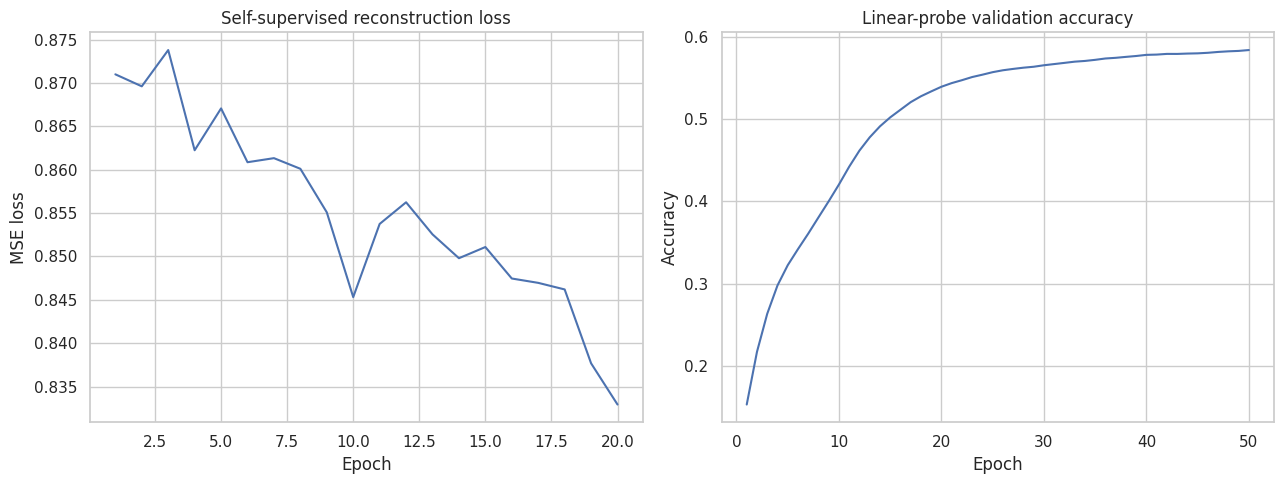

In [13]:
fig, axes = plt.subplots(1,2,figsize=(13,5))
axes[0].plot(pretraining_history.epoch, pretraining_history.reconstruction_loss)
axes[0].set(title='Self-supervised reconstruction loss', xlabel='Epoch', ylabel='MSE loss')
axes[1].plot(probe_history.epoch, probe_history.validation_accuracy)
axes[1].set(title='Linear-probe validation accuracy', xlabel='Epoch', ylabel='Accuracy')
plt.tight_layout(); plt.savefig(OUTPUT / 'self_supervised_results.png', dpi=250); plt.show()

## 12.3 Interpretation

A decreasing reconstruction loss indicates that the encoder learned information from the graph and node features without category labels. The linear evaluation measures whether those embeddings support classification. The result may be lower than supervised training because the reconstruction objective and classification objective are different.